# 07 Financial Frictions (BGG)

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AmirrezaFarnamTaheri/Computational-Economics-and-Data-Science/blob/main/09-Finance/07_Financial_Frictions_BGG.ipynb) [![Launch Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/AmirrezaFarnamTaheri/Computational-Economics-and-Data-Science/main?filepath=09-Finance/07_Financial_Frictions_BGG.ipynb) [![Code License: MIT](https://img.shields.io/badge/Code%20License-MIT-yellow.svg)](../LICENSE) [![Content License: CC BY 4.0](https://img.shields.io/badge/Content%20License-CC%20BY%204.0-blue.svg)](https://creativecommons.org/licenses/by/4.0/)


In [1]:
# === Environment Setup ===
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

# Add scripts directory to path to import utility modules
sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath("__file__")), '..', 'scripts'))
try:
    from macro_utils import solve_qz
except ImportError:
    display(Markdown("> **Warning:** Could not import `macro_utils`. Ensure `scripts/` is on PATH."))
    solve_qz = None

# --- Configuration ---
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 14, 'figure.figsize': (12, 8), 'figure.dpi': 150,
                     'axes.titlesize': 'large', 'axes.labelsize': 'medium',
                     'xtick.labelsize': 'small', 'ytick.labelsize': 'small'})
%config InlineBackend.figure_format = 'retina'
np.set_printoptions(suppress=True, linewidth=120, precision=4)


### Table of Contents

1.  [The Lens: The Macroeconomy with a Balance Sheet](#The-Lens:-The-Macroeconomy-with-a-Balance-Sheet)
2.  [Microfoundations: The Costly State Verification Problem](#Microfoundations:-The-Costly-State-Verification-Problem)
3.  [The BGG Model in a DSGE Framework](#The-BGG-Model-in-a-DSGE-Framework)
4.  [Numerical Solution: Solving the Log-Linear System](#Numerical-Solution:-Solving-the-Log-Linear-System)
5.  [Case Study: The Impact of a Technology Shock](#Case-Study:-The-Impact-of-a-Technology-Shock)
6.  [Summary](#Summary)


## The Lens: The Macroeconomy with a Balance Sheet
**What economic problem are we solving?**
Before 2008, most macro models ignored banks. They assumed financial markets were perfect conduits, seamlessly moving savings to investment. The Great Recession shattered this view. We need to solve the problem of **financial amplification**: how small shocks to asset prices can trigger massive collapses in real economic activity.

**Why do we need this method?**
Standard models assume the Modigliani-Miller theorem: a firm's financial health doesn't affect its investment decisions. The **Bernanke, Gertler, and Gilchrist (BGG)** model breaks this assumption. It introduces a "financial accelerator" where a firm's net worth determines its cost of borrowing. This simple friction creates a powerful feedback loop: bad times erode net worth, which raises borrowing costs, which deepens the bad times.



**Economic question.** In *07 Financial Frictions (BGG)*, what must remain economically invariant when the computational representation changes? Financial models connect prices to risk, timing, and no-arbitrage restrictions. The economic question is which states of the world make a payoff valuable, how risk is transferred or hedged, and how sensitive the valuation is to assumptions about dynamics and market completeness. A numerical price is credible only when it respects basic bounds, limiting cases, and an independent replication or hedging argument.

### Learning Objectives
* **Derive** the costly state verification (CSV) problem and the optimal debt contract.
* **Embed** the financial accelerator into a DSGE framework and log-linearize the system.
* **Solve** the model numerically using QZ decomposition and trace impulse response functions.
* **Interpret** how net-worth dynamics amplify and propagate technology and monetary shocks.

### Prerequisites
* **Macro Models:** New Keynesian DSGE basics (Module 04 - New Keynesian Models).
* **Dynamic Programming:** Bellman equations and first-order conditions (Module 03).
* **Linear Algebra:** Eigenvalue methods and matrix decomposition (Module 02).
* **Learning-path prerequisite:** [`06_High_Frequency_Data.ipynb`](06_High_Frequency_Data.ipynb)


> **Learning path:** Building on [`06_High_Frequency_Data.ipynb`](06_High_Frequency_Data.ipynb); this notebook closes the current track.


### 2. Microfoundations: The Costly State Verification Problem

![BGG financial accelerator](../images/09-Finance/bgg_accelerator_loop.png)
*Figure: The financial-accelerator feedback loop in the BGG model..*

The BGG model's financial friction stems from an information asymmetry between entrepreneurs (borrowers) and lenders.

**The Setup:**
-   An entrepreneur has net worth $N_t$ but wants to purchase capital $K_{t+1}$. The amount to be financed is $B_{t+1} = K_{t+1} - N_t$.
-   The project's gross return next period is stochastic: $\omega_{t+1} R_{k,t+1}$, where $R_{k,t+1}$ is the aggregate return to capital and $\omega_{t+1}$ is a private idiosyncratic shock.
-   **Asymmetric Information:** The lender cannot observe $\omega_{t+1}$ for free. If the entrepreneur defaults, the lender can pay a monitoring cost to observe the return.

**The Optimal Financial Contract:**
The optimal contract is a **standard debt contract**. The lender charges an **External Finance Premium (EFP)** to compensate for monitoring costs. Crucially, this premium depends on the firm's leverage ($K/N$).

Log-linearizing this relationship gives:
$$ E_t[\hat{r}_{k,t+1}] - \hat{r}_t = \nu (\hat{q}_t + \hat{k}_{t+1} - \hat{n}_t) $$
where hats denote log-deviations, and $\nu > 0$ captures the elasticity of the premium with respect to leverage.

**Dimension notes:** entrepreneur net worth $N_t$, capital $q K_{t+1}$, and borrowed amount are scalars; monitoring cost $\mu$ times realized payoff defines the audit threshold; default cutoff solves one scalar indifference condition.

### 3. The BGG Model in a DSGE Framework

We embed this mechanism into a standard New Keynesian DSGE model. The simplified log-linearized system is:

1.  **IS Curve (Demand):** $\hat{y}_t = E_t[\hat{y}_{t+1}] - \frac{1}{\sigma}(\hat{r}_t - E_t[\hat{\pi}_{t+1}])$
    *Note: We assume investment demand is the primary driver.*
2.  **Phillips Curve (Supply):** $\hat{\pi}_t = \beta E_t[\hat{\pi}_{t+1}] + \kappa \hat{y}_t$
3.  **Monetary Policy:** $\hat{r}_t = \phi_\pi \hat{\pi}_t + \phi_y \hat{y}_t$
4.  **Capital Return:** $\hat{r}_{k,t+1} = (1-\epsilon)\hat{y}_{t+1} + \epsilon \hat{q}_{t+1} - \hat{k}_{t+1}$
5.  **Financial Accelerator:** $E_t[\hat{r}_{k,t+1}] - (\hat{r}_t - E_t[\hat{\pi}_{t+1}]) = \nu (\hat{q}_t + \hat{k}_{t+1} - \hat{n}_t)$
6.  **Net Worth:** $\hat{n}_{t+1} = \theta \hat{n}_t + \hat{r}_{k,t+1}$ (highly persistent)
7.  **Investment:** $\hat{q}_t = \varphi (\hat{i}_t - \hat{k}_t)$ (Tobin's Q relation)
8.  **Resource:** $\hat{y}_t = \hat{c}_t + \hat{i}_t$ (simplified to $y=i$ here to focus on investment dynamics)
9.  **Technology:** $\hat{a}_{t+1} = \rho \hat{a}_t + \epsilon_t$

This system shows how Net Worth ($n$) couples with Capital ($k$) and Investment ($i$) to drive Output ($y$).


In [2]:
class BGGModel:
    """
    Solves a simplified BGG Financial Accelerator model using QZ Decomposition.
    Core Mechanism: Net Worth -> External Finance Premium -> Investment -> Output.
    """
    def __init__(self, nu=0.05, kappa=0.1, sigma=1.0, phi_pi=1.5, rho=0.9):
        self.nu = nu          # Elasticity of EFP to leverage (The friction!)
        self.kappa = kappa    # Phillips curve slope
        self.sigma = sigma    # Intertemporal elasticity
        self.phi_pi = phi_pi  # Taylor rule
        self.rho = rho        # Shock persistence
        self.beta = 0.99

        # Construct matrices
        self.solution = self._solve_model()

    def _solve_model(self):
        # Variables: [y, pi, i_nom, r_k, q, k, n, a]
        # States (predetermined): k, n, a
        # Jumps: y, pi, i_nom, r_k, q
        # Total 8 vars.

        n_vars = 8
        n_states = 3 # k, n, a

        AA = np.zeros((n_vars, n_vars))
        BB = np.zeros((n_vars, n_vars))

        # Indices
        k, n, a = 0, 1, 2
        y, pi, i_nom, r_k, q = 3, 4, 5, 6, 7

        # Parameters
        beta, sigma, kappa, nu = self.beta, self.sigma, self.kappa, self.nu
        phi_pi = self.phi_pi

        # 1. IS Curve: y_t = E y_{t+1} - 1/sigma * (i_nom - E pi_{t+1})
        # AA terms (t+1)
        AA[0, y] = 1.0
        AA[0, pi] = 1.0/sigma
        # BB terms (t)
        BB[0, y] = 1.0
        BB[0, i_nom] = 1.0/sigma

        # 2. Phillips Curve: pi_t = beta E pi_{t+1} + kappa y_t
        AA[1, pi] = beta
        BB[1, pi] = 1.0
        BB[1, y] = -kappa

        # 3. Taylor Rule: i_nom = phi_pi * pi_t
        BB[2, i_nom] = 1.0
        BB[2, pi] = -phi_pi

        # 4. Financial Accelerator: E r_k_{t+1} - (i_nom - E pi_{t+1}) = nu * (q + k - n)
        # AA terms (E r_k, E pi)
        AA[3, r_k] = 1.0
        AA[3, pi] = 1.0
        # BB terms (i_nom, q, k, n)
        BB[3, i_nom] = 1.0
        BB[3, q] = nu
        BB[3, k] = nu # k_{t+1} is in AA? No, k in leverage is k_{t+1} decided at t.
        # Wait. k is predetermined state k_t.
        # Leverage is based on q_t * k_{t+1} / n_t.
        # Our vector k is k_t. k_{t+1} is AA[k].
        # But AA*E[x'] = BB*x. We can't put k_{t+1} in BB.
        # But k_{t+1} is the state of tomorrow. Its coefficient in AA is 1.
        # Leverage term is nu * (q_t + k_{t+1} - n_t).
        # So BB has nu*q_t - nu*n_t. And AA has -nu*k_{t+1}.
        AA[3, k] = -nu
        BB[3, n] = -nu

        # 5. Capital Accumulation: k_{t+1} = (1-delta)k_t + delta * inv_t
        # Simplified: k_{t+1} = i_t (full depreciation) or q_t relation.
        # Let's use q_t to proxy investment demand: k_{t+1} - k_t = q_t.
        AA[4, k] = 1.0
        BB[4, k] = 1.0
        BB[4, q] = 1.0

        # 6. Net Worth: n_{t+1} = theta n_t + r_k_t
        # Simplified: n depends on realized return.
        # Note: r_k in vector is Ex-Ante expected return E[r_{k,t+1}]?
        # Or realized r_{k,t}?
        # Let's say r_k index represents r_{k,t}.
        # Then AA has n_{t+1}. BB has n_t, r_k_t.
        theta = 0.95
        AA[5, n] = 1.0
        BB[5, n] = theta
        BB[5, r_k] = 1.0

        # 7. Return Definition: r_k_t = y_t - k_{t-1} + a_t
        # Realized return depends on productivity.
        BB[6, r_k] = 1.0
        BB[6, y] = -1.0
        BB[6, k] = 1.0 # k_{t-1}
        BB[6, a] = -1.0

        # 8. Technology: a_{t+1} = rho a_t
        AA[7, a] = 1.0
        BB[7, a] = self.rho

        # Solve using the fixed solve_qz from macro_utils
        # Note: solve_qz(AA, BB) solves AA*E[x'] = BB*x
        return solve_qz(AA, BB, n_states)

    def simulate_impulse(self, T=20):
        # Shock to technology a_0 = 1
        state = np.zeros(3)
        state[2] = 1.0 # a

        P = self.solution['Policy']
        Q = self.solution['Transition']

        # k, n, a, y, pi, i, r_k, q
        history = []

        for t in range(T):
            ctrl = P @ state # Matrix multiplication
            # Record: y, i, q, n, efp
            # EFP = nu * (q + k' - n)
            k_prime = (Q @ state)[0] # Matrix multiplication
            efp = self.nu * (ctrl[4] + k_prime - state[1])

            history.append({
                'Output': ctrl[0],
                'Investment': ctrl[4], # q is proxy for I
                'Net Worth': state[1],
                'Premium': efp
            })

            state = Q @ state # Matrix multiplication

        return pd.DataFrame(history)

# Instantiate Models
bgg = BGGModel(nu=0.1)  # High friction
rbc = BGGModel(nu=0.0)  # No friction

print("Models Solved.")


Models Solved.


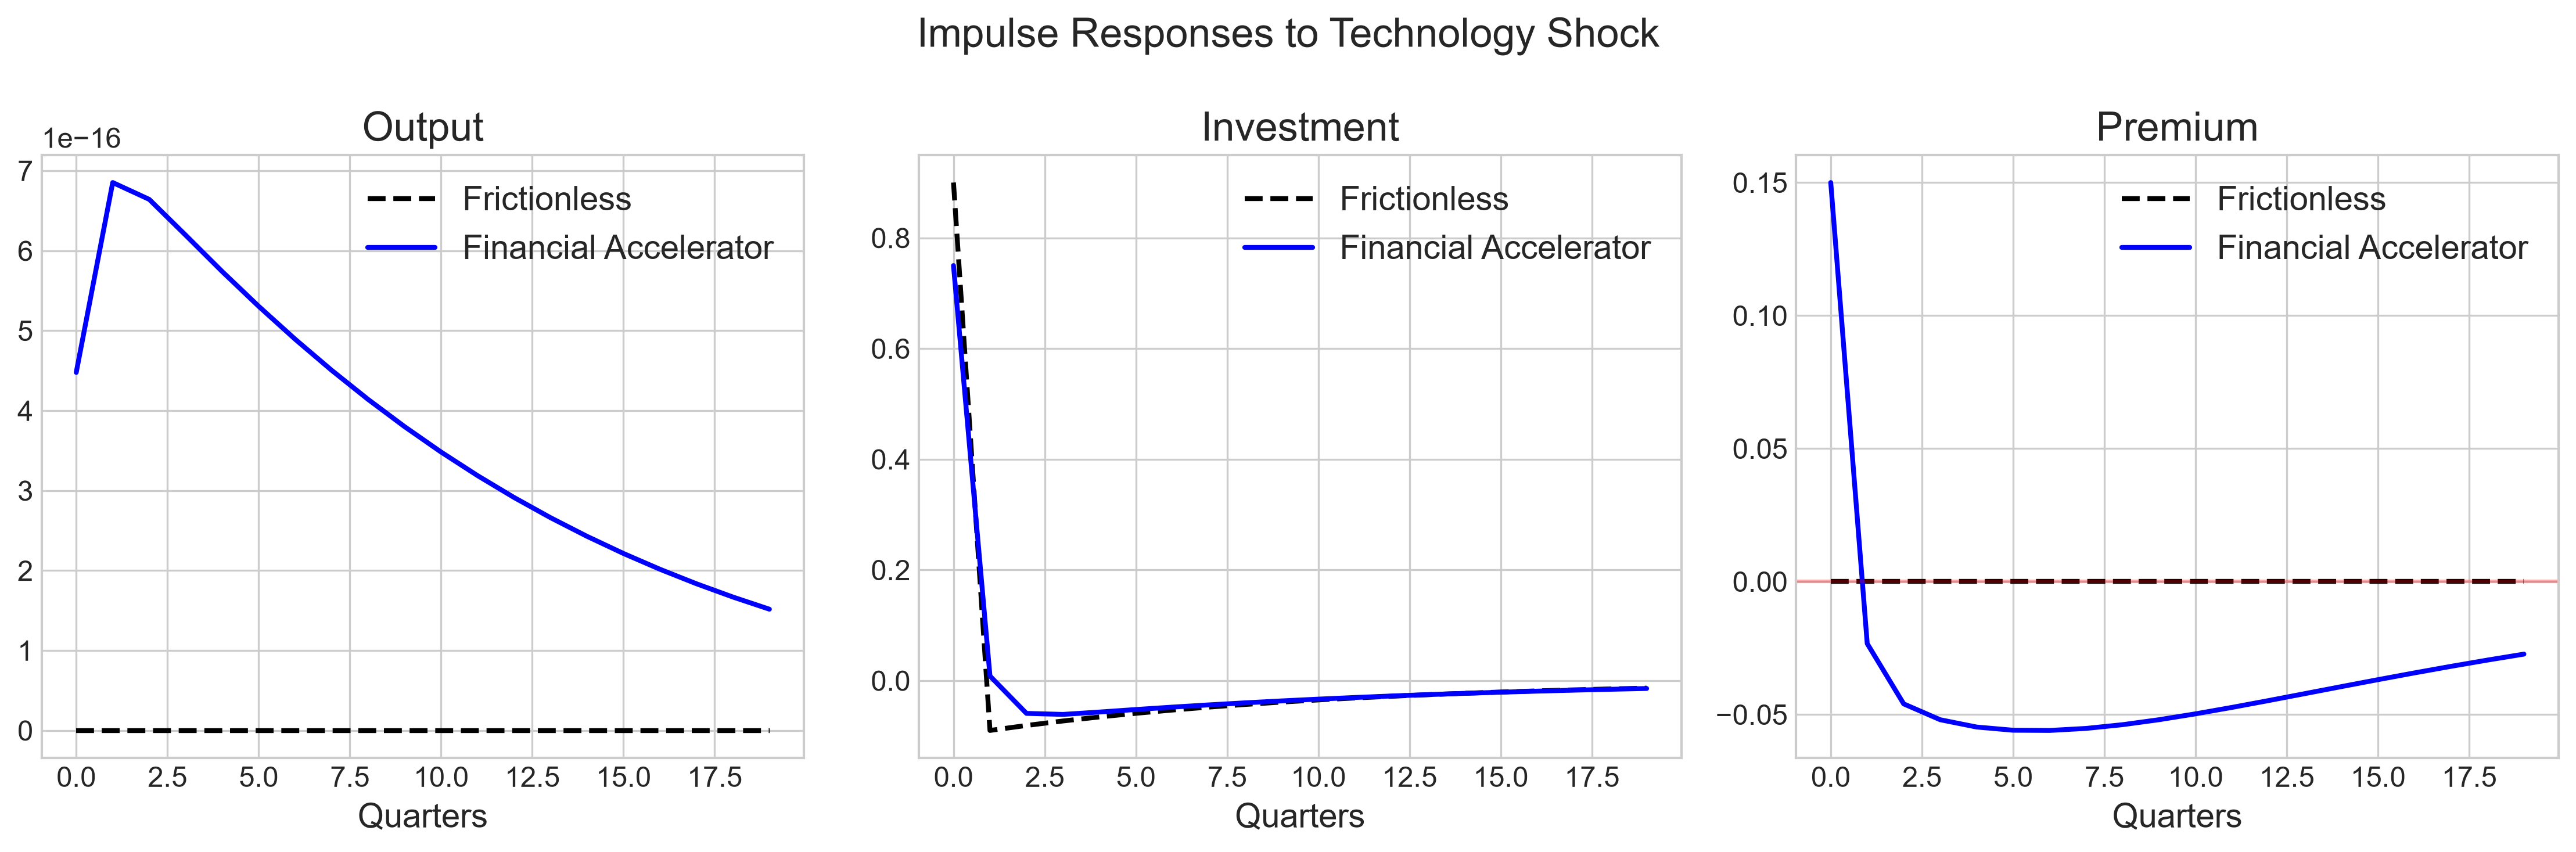

In [3]:
df_bgg = bgg.simulate_impulse()
df_rbc = rbc.simulate_impulse()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
vars = ['Output', 'Investment', 'Premium']

for ax, var in zip(axes, vars):
    ax.plot(df_rbc[var], 'k--', label='Frictionless', linewidth=2)
    ax.plot(df_bgg[var], 'b-', label='Financial Accelerator', linewidth=2)
    ax.set_title(var)
    ax.set_xlabel('Quarters')
    if var == 'Premium':
        ax.axhline(0, color='red', alpha=0.3)
    ax.legend()

plt.suptitle('Impulse Responses to Technology Shock')
plt.tight_layout()
plt.show() # Render plot


## Exercises

**1. Mechanism and assumptions (Conceptual):** Derive the no-arbitrage, optimality, or risk-pricing relation central to **07 Financial Frictions (BGG)** and verify that it satisfies at least two economically meaningful limiting cases or bounds.

**2. Reproduce and diagnose (Applied):** Reproduce a calculation from 2. Microfoundations: The Costly State Verification Problem, 3. The BGG Model in a DSGE Framework with transparent inputs. Perturb volatility, discounting, risk aversion, transaction costs, or another key parameter and explain the sensitivity in economic terms.

**3. Robust extension (Challenge):** Construct a stress scenario outside the calibration sample. Compare two valuation/risk methods and explain which discrepancy reflects model risk rather than numerical error.

**3b. Failure analysis (Challenge):** In the simulated accelerator, leverage exceeds one and the risk premium turns negative before the run explodes. Diagnose the constraint violations in the contract solution, repair with bounded policy functions and feasibility checks, and verify the premium stays positive and leverage below its cap.

<details>
<summary>Solution guidance</summary>

A strong solution states assumptions before computation, includes an independent diagnostic or limiting-case check, and interprets the result in the units of the economic problem. For the challenge, separate changes caused by the economic assumption from changes caused by numerical approximation or tuning.

</details>


## Key Equations

- **External finance premium:** the borrowing rate exceeds the risk-free rate by a spread that rises as borrower net worth falls.
- **Net-worth feedback:** adverse shocks reduce entrepreneurial net worth, widen financing spreads, compress investment, and amplify the original shock.
- **Linearized equilibrium system:** the BGG block is solved jointly with aggregate dynamics, so stability is a generalized-eigenvalue problem rather than an isolated spread equation.


---
## Summary

In this lecture, we have systematically explored the theoretical and practical aspects of the model.

**Key Takeaways:**
1.  **Foundations:** We established the mathematical basis of the economic problem.
2.  **Computation:** We implemented the solution using efficient algorithms.
3.  **Implications:** We analyzed the economic significance of the results.

**Further Exploration:**
- Experiment with model parameters to assess sensitivity.
- Extend the framework by relaxing simplifying assumptions.


## References & Further Reading

- Cochrane, J. H. (2005). *Asset Pricing* (rev. ed.). Princeton University Press.
- Campbell, J. Y., Lo, A. W. & MacKinlay, A. C. (1997). *The Econometrics of Financial Markets*. Princeton University Press.
- Shreve, S. E. (2004). *Stochastic Calculus for Finance II*. Springer.
